# Problem 2
***

### a)

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import islice
from scipy.stats import rankdata


In [3]:
# Define the ticker. For each of the tickers I add the corresponding names

tickers = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'BP': 'BP plc',
    'JNJ': 'Johnson & Johnson',
    'NVS': 'Novartis AG',
    'KO': 'The Coca Cola Company',
    'UL': 'Unilever Plc',
    'JPM': 'JP Morgan Chase & Co',
    'BCS': 'Barclays Plc',
    'SONY': 'Sony',
    '^GSPC': 'S&P Index 500'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-05-31'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
#Adjusted close column with the correct index. 
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date, ignore_tz=True)['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
# Assuming that the question asks for all the periods log return. 

log_return_1 = {}

# The 1-day log return, stored for each of the assets 

for ticker, name in tickers.items():
    log_return_1[name] = np.log(data[name] / data[name].shift(1))


In [5]:
# The 30-day returns are as follows:

log_return_30 = {}

for ticker, name in tickers.items():
    log_return_30[name] = log_return_1[name].rolling(30).sum()

In [6]:
# The 252-day returns are as follows:

log_return_252 = {}

for ticker, name in tickers.items():
    log_return_252[name] = log_return_1[name].rolling(252).sum()
    

In [7]:
# Changing to pandas dataframe 

log_return_1 = pd.DataFrame(log_return_1)
log_return_30 = pd.DataFrame(log_return_30)
log_return_252 = pd.DataFrame(log_return_252)

##### All log returns are calculated, but I wont display them because they are so many.

***
### b)

In [11]:
# Define the average periods
periods = [1, 30, 252]

# Create an empty DataFrame with row and column names
average = pd.DataFrame()

standard_deviation = pd.DataFrame()

In [12]:
# Creating a matrix with the different names and periods. 
for ticker, name in tickers.items():
    average.loc[f"Period 1 Day",name] = log_return_1[name].mean()
    standard_deviation.loc[f"Period 1 Day",name] = log_return_1[name].std()

for ticker, name in tickers.items():
    average.loc[f"Period 30 Day",name] = log_return_30[name].mean()
    standard_deviation.loc[f"Period 30 Day",name] = log_return_30[name].std()

for ticker, name in tickers.items():
    average.loc[f"Period 252 Day",name] = log_return_252[name].mean()
    standard_deviation.loc[f"Period 252 Day",name] = log_return_252[name].std()


In [13]:
display(standard_deviation)
display(average)

,Apple,Microsoft,BP plc,Johnson & Johnson,Novartis AG,The Coca Cola Company,Unilever Plc,JP Morgan Chase & Co,Barclays Plc,Sony,S&P Index 500
Period 1 Day,0.018197,0.017092,0.019363,0.011125,0.011613,0.011337,0.013301,0.016855,0.023362,0.019619,0.011057
Period 30 Day,0.096115,0.069903,0.101242,0.052303,0.060101,0.052577,0.057592,0.081120,0.130111,0.102507,0.051638
Period 252 Day,0.249205,0.170524,0.264268,0.091846,0.134305,0.086803,0.120074,0.210803,0.305189,0.253692,0.120009


,Apple,Microsoft,BP plc,Johnson & Johnson,Novartis AG,The Coca Cola Company,Unilever Plc,JP Morgan Chase & Co,Barclays Plc,Sony,S&P Index 500
Period 1 Day,0.000899,0.001024,0.000160,0.000407,0.000352,0.000300,0.000228,0.000538,-0.000175,0.000805,0.000403
Period 30 Day,0.028216,0.030259,0.005117,0.012337,0.010786,0.009761,0.007582,0.015787,-0.005813,0.022752,0.011834
Period 252 Day,0.248290,0.240908,0.033392,0.098598,0.065932,0.078242,0.052563,0.122932,-0.056112,0.161814,0.093996


In [19]:
# Assuming I should rank them by the average of the log return of 252 days.

rank = np.array([tickers, rankdata(-1*average["Period 252 Day":])])
display(rank)

C:\Users\malvi\AppData\Local\Temp\ipykernel_24548\2291441593.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  rank = np.array([tickers, rankdata(-1*average["Period 252 Day":])])


array([{'AAPL': 'Apple', 'MSFT': 'Microsoft', 'BP': 'BP plc', 'JNJ': 'Johnson & Johnson', 'NVS': 'Novartis AG', 'KO': 'The Coca Cola Company', 'UL': 'Unilever Plc', 'JPM': 'JP Morgan Chase & Co', 'BCS': 'Barclays Plc', 'SONY': 'Sony', '^GSPC': 'S&P Index 500'},
       array([ 1.,  2., 10.,  5.,  8.,  7.,  9.,  4., 11.,  3.,  6.])],
      dtype=object)

##### We can see from the table that Apple has the best average log return over a 252 day hold. 

***
### c) 

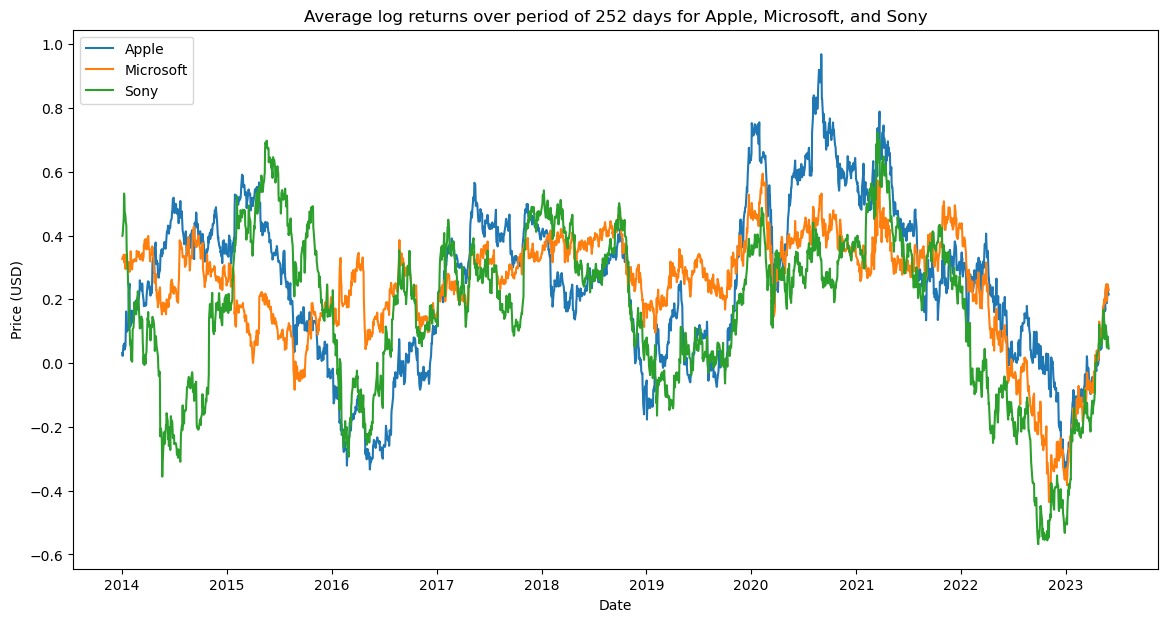

In [22]:
top_stocks = ['Apple', 'Microsoft', 'Sony']

# Plotting the closing prices for Apple, Microsoft, and Sony
plt.figure(figsize=(14, 7))  

# Loop over the tickers
for ticker in top_stocks:
    df = log_return_252[ticker]
    plt.plot(df, label=ticker)

plt.title('Average log returns over period of 252 days for Apple, Microsoft, and Sony')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')

plt.show()


##### The three log returns over time are following each other pretty nicely. However, there is one specific difference between Sony and the other two around 2014(it counts the last year, so when it goes down there is a bad period). It looks like the stocks have some down periods that makes the average go under 0. This means that if you invested in these time periods, you are likely to lose value. After the war in Ukraine we also see a decrease in the average rolling 252. Overall in good periods, the log returns seem alright.

***
### d) 

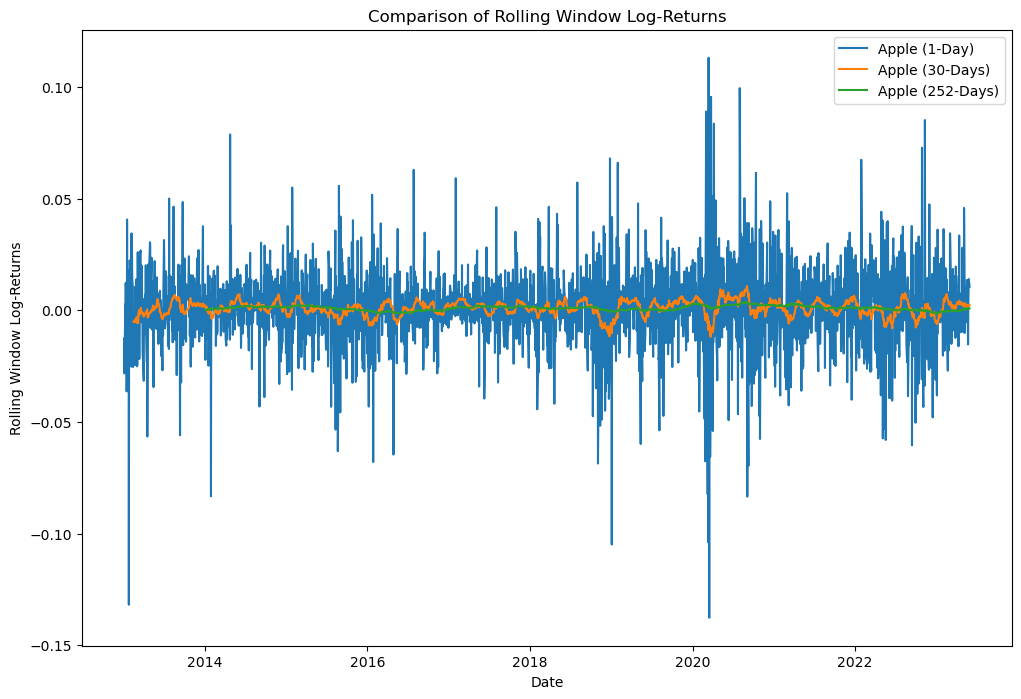

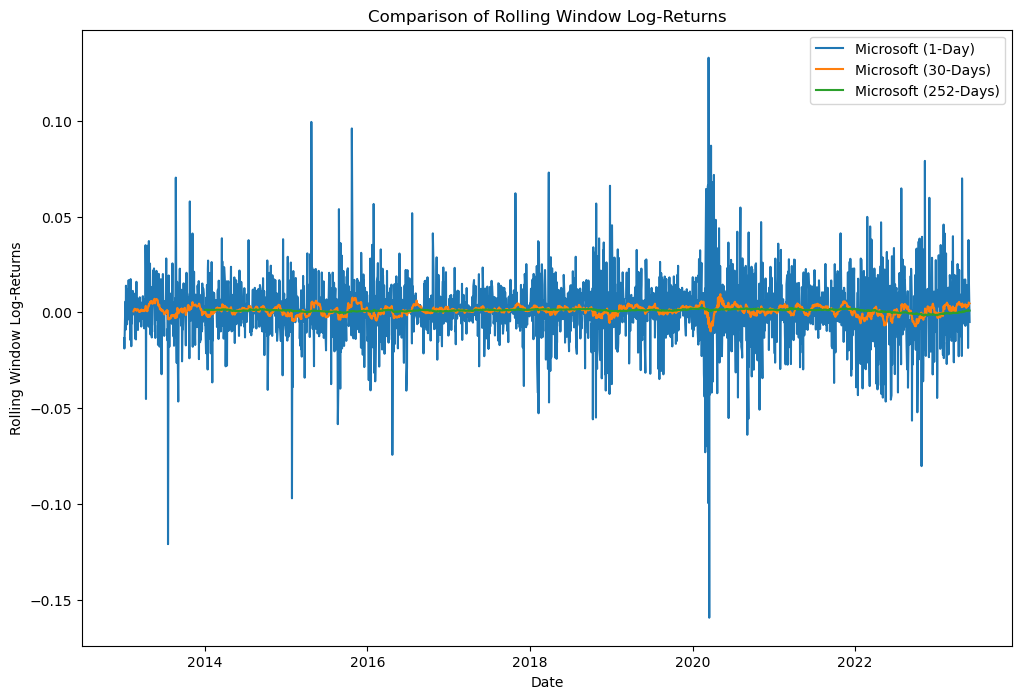

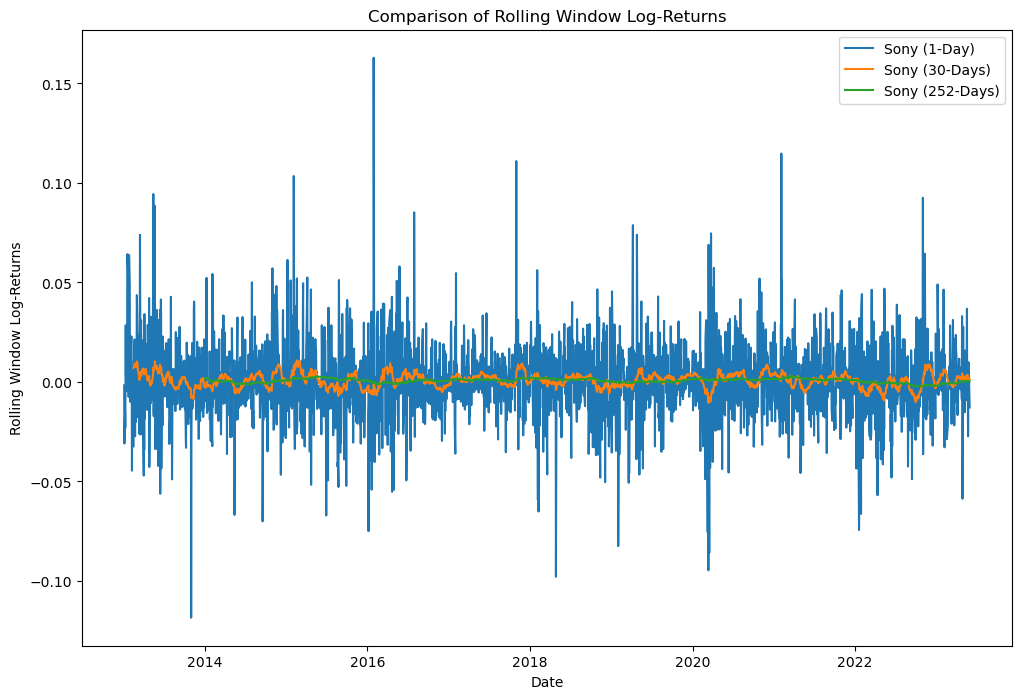

In [23]:
# Loop over the top stocks
for ticker in top_stocks:
    plt.figure(figsize=(12, 8))
    # Get the corresponding DataFrame
    df = data[ticker]

    # Plot the rolling windows. For it to make more sense i divide by number of days in the period to find the per day average change.
    plt.plot(df.index, log_return_1[ticker], label=f'{ticker} (1-Day)')
    plt.plot(df.index, log_return_30[ticker]/30, label=f'{ticker} (30-Days)')
    plt.plot(df.index, log_return_252[ticker]/252, label=f'{ticker} (252-Days)')

    plt.title('Comparison of Rolling Window Log-Returns')
    plt.xlabel('Date')
    plt.ylabel('Rolling Window Log-Returns')
    plt.legend()
    plt.show()




##### By looking at the plots we cannot see a lot about the 252 holding log average. The periods with the largest downfalls and growths are often accompanied by sudden changes in the 30 day holding log average. Its difficult to see much of a pattern elsewhere.

***
### e)

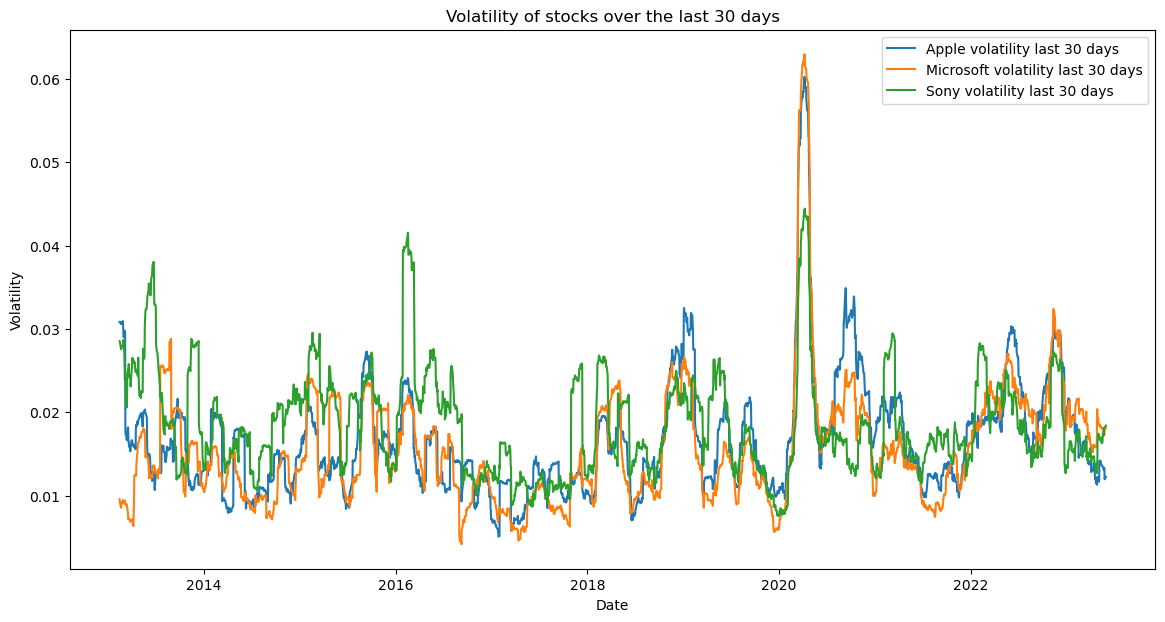

In [14]:
# Thinking that a rolling standard deviation of 30 days makes sense to find the volatility of the period.  
rolling_std = {}
plt.figure(figsize = (14,7))
for ticker in top_stocks:
    rolling_std[ticker] = log_return_1[ticker].rolling(30).std()
    plt.plot(rolling_std[ticker], label=f"{ticker} volatility last 30 days")
    plt.title('Volatility of stocks over the last 30 days')
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    



##### We can see that the volatility of the three stocks follows each other pretty good, again as the average rolling. They are not changing that much, but some periods they are extremely large, and one would therefore try and avoid these spikes to avoid severe downfalls. It looks like sony is the one with the most spikes, and could therefore be more risky than the other two assets. 

***
### f)

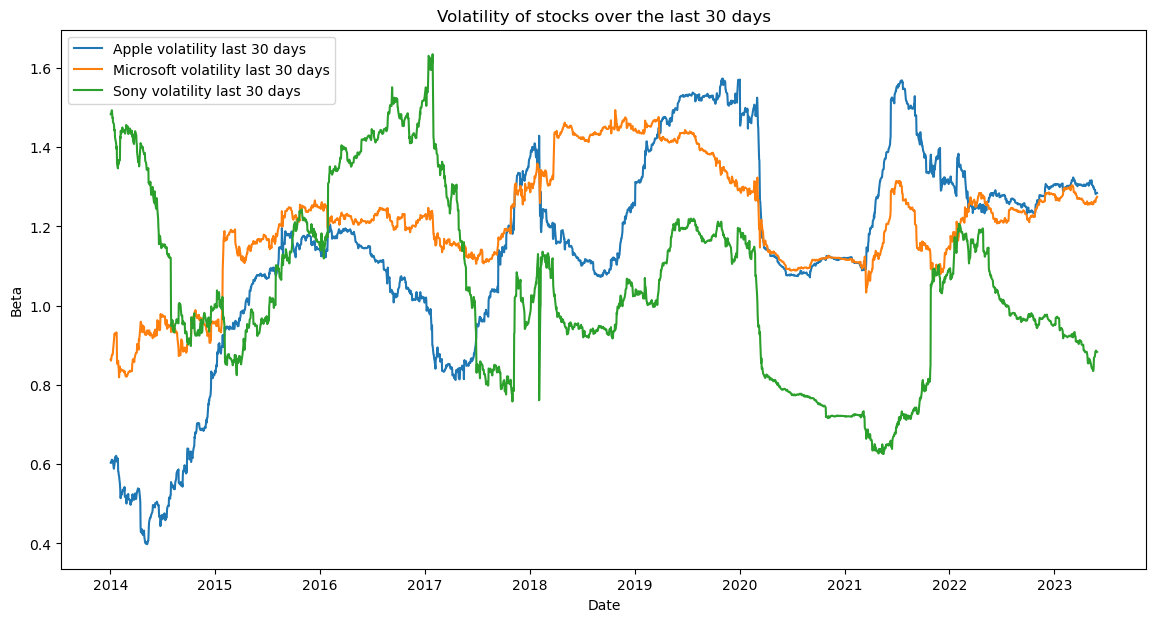

In [31]:
# Using the rolling log return on the S&P index 500 as the market return. 
beta = {}
plt.figure(figsize=(14,7))

# Using lecture notes on chapter two to find the beta. Rolling 252 to find the rolling beta to the market. 

for ticker in top_stocks:
    beta[ticker] = log_return_1[ticker].rolling(252).corr(log_return_1["S&P Index 500"])*log_return_1[ticker].rolling(252).std()/log_return_1["S&P Index 500"].rolling(252).std()
    plt.plot(beta[ticker], label=f"{ticker} volatility last 30 days")

plt.title('Volatility of stocks over the last 30 days')
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
    
    

##### The Betas are kind of all over the place. We see that they are going both over and under the market beta. If you want to be less risky, you should go for the lower volatility and lower beta, and opposite for if you want to be risky. Here Sony has a period that it is most risky with a beta on around 1.4 around 2016-2017, but four years later it is the least risky of the three stocks on around 0.75. 
##### When looking at the answers in c and e we see that there is not much more to conclude on. The riskiness of Sony in earlier years are visible in the other plots as well.